# Comparing image attention explanations

**Input:** two author-released illustrative images (`catdog`, `el2`), two target ImageNet classes per image. **Model:** original author ViT-B/16 checkpoint, converted without changing its weights. **Tools:** eight attention attribution/propagation methods and actual patch-deletion curves.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


Input: catdog | model: ViT-B/16 · original jx_vit_base_p16_224-80ecf9dd checkpoint


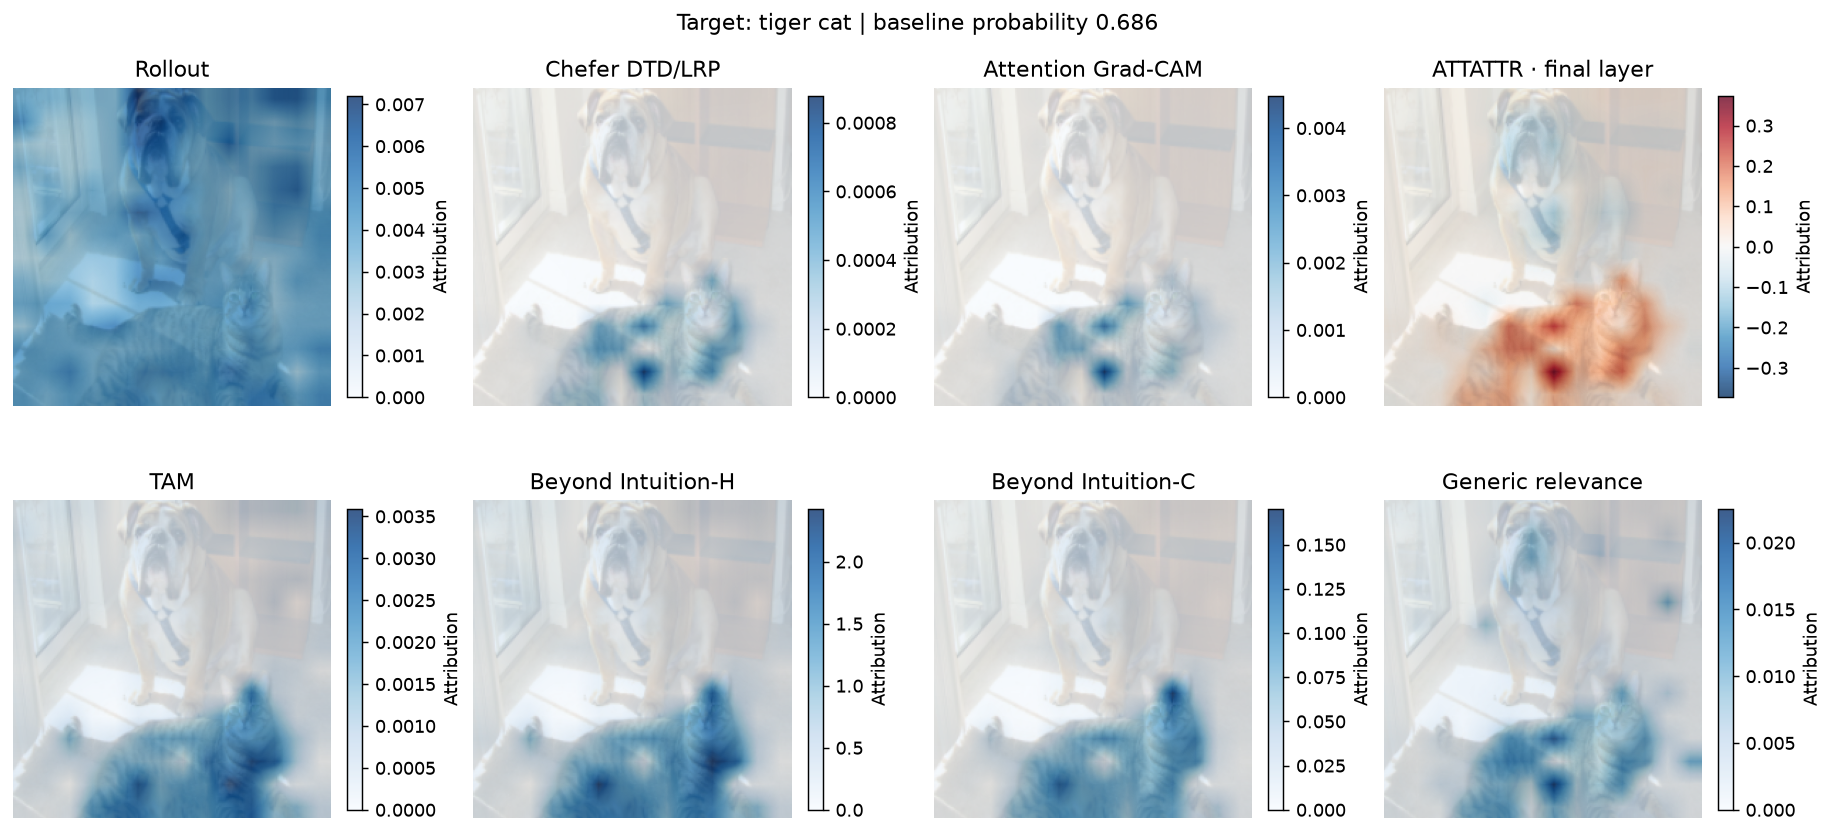

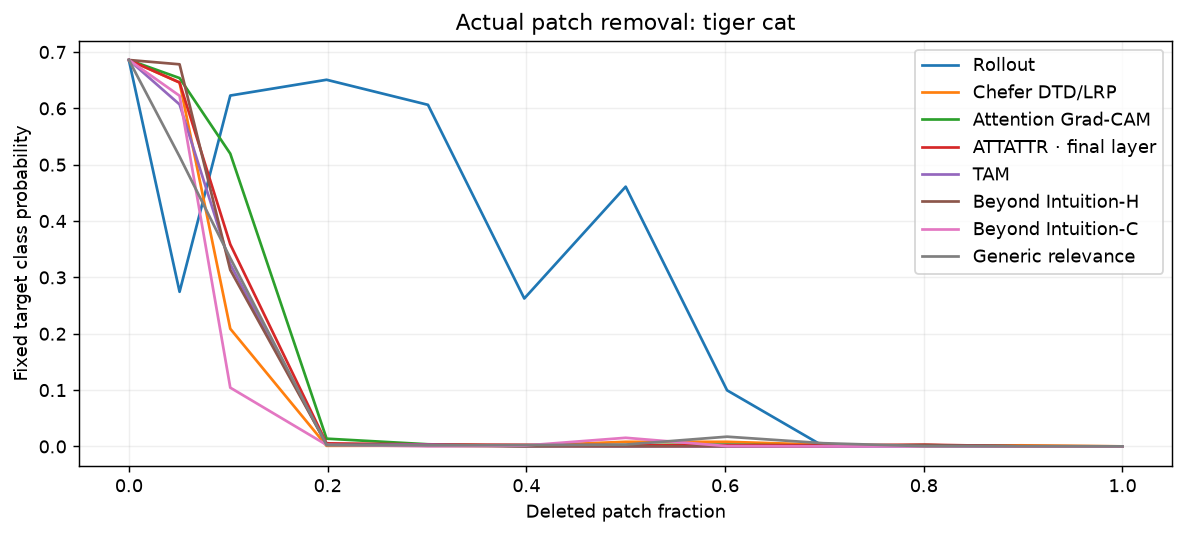

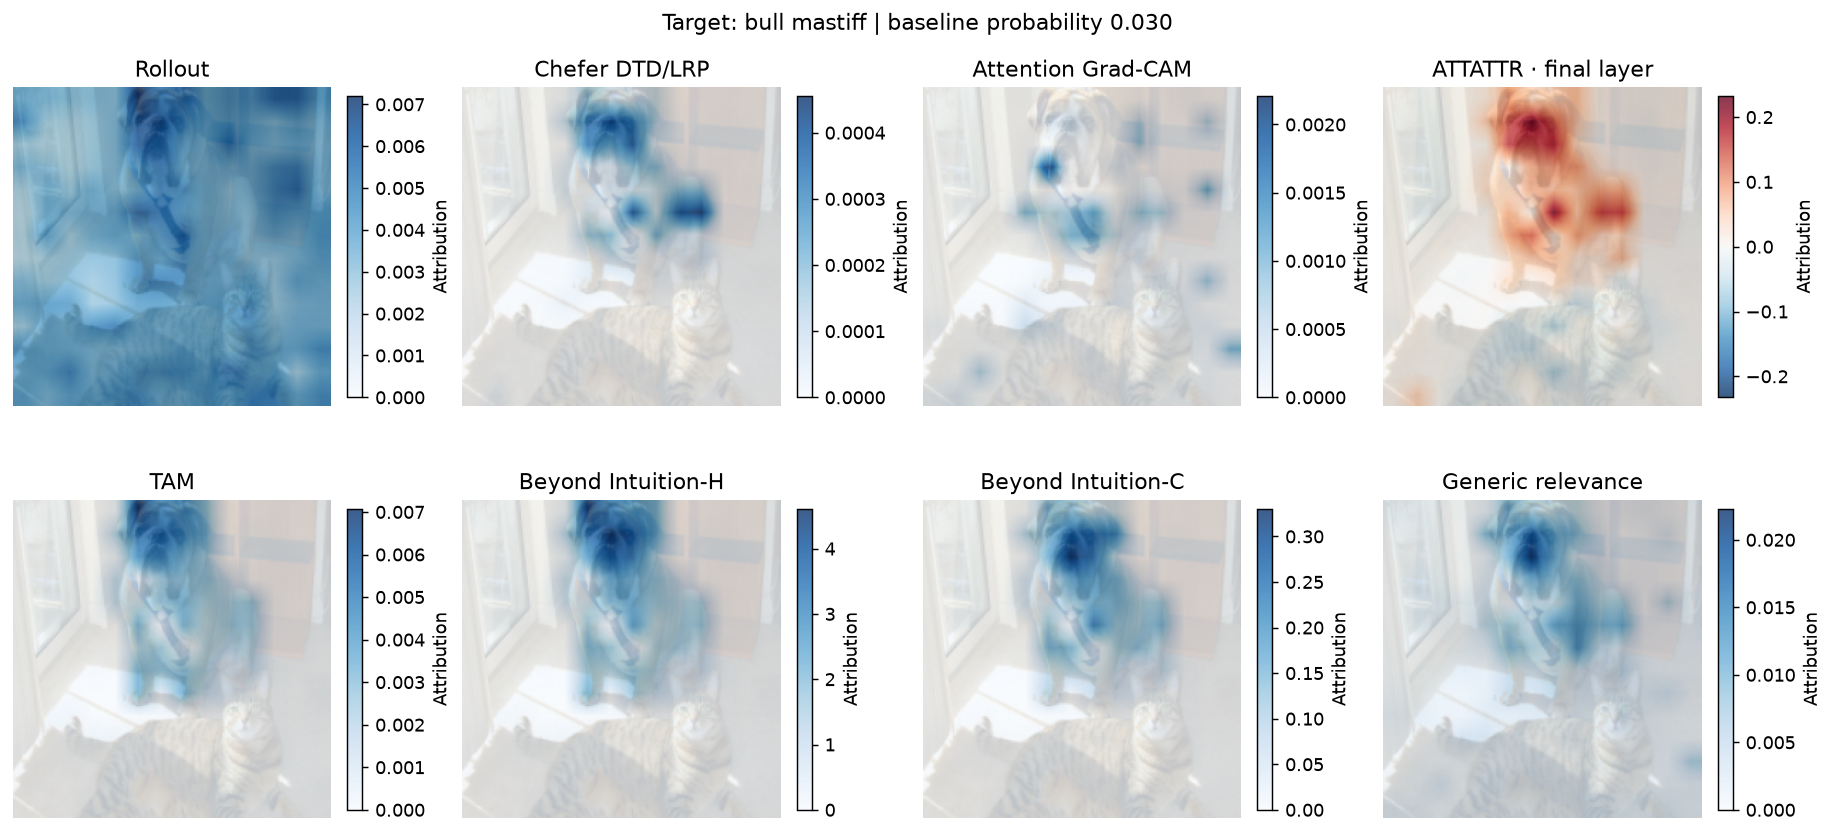

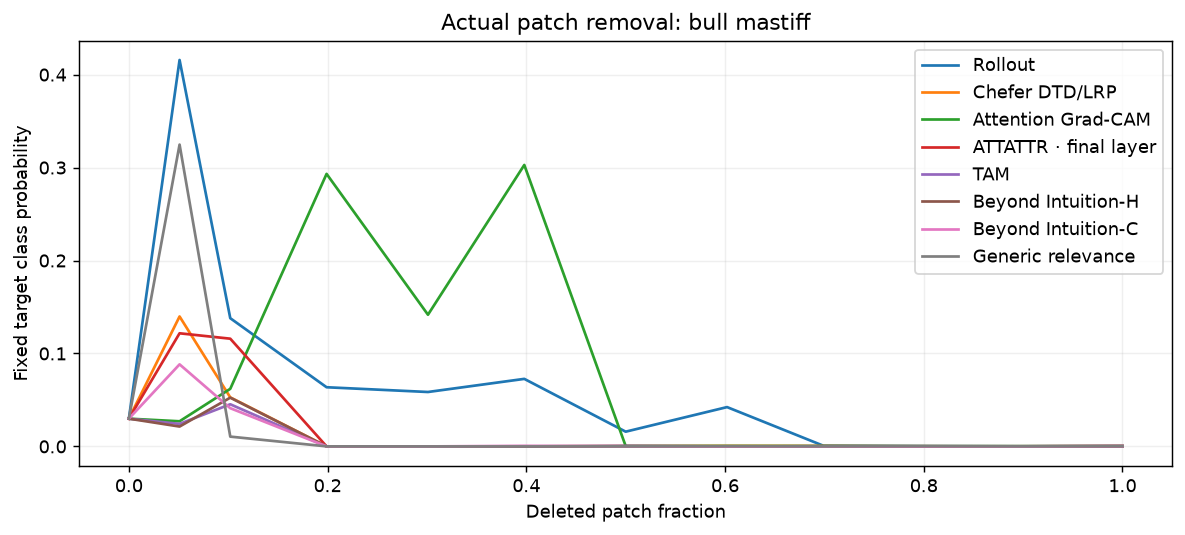

Input: el2 | model: ViT-B/16 · original jx_vit_base_p16_224-80ecf9dd checkpoint


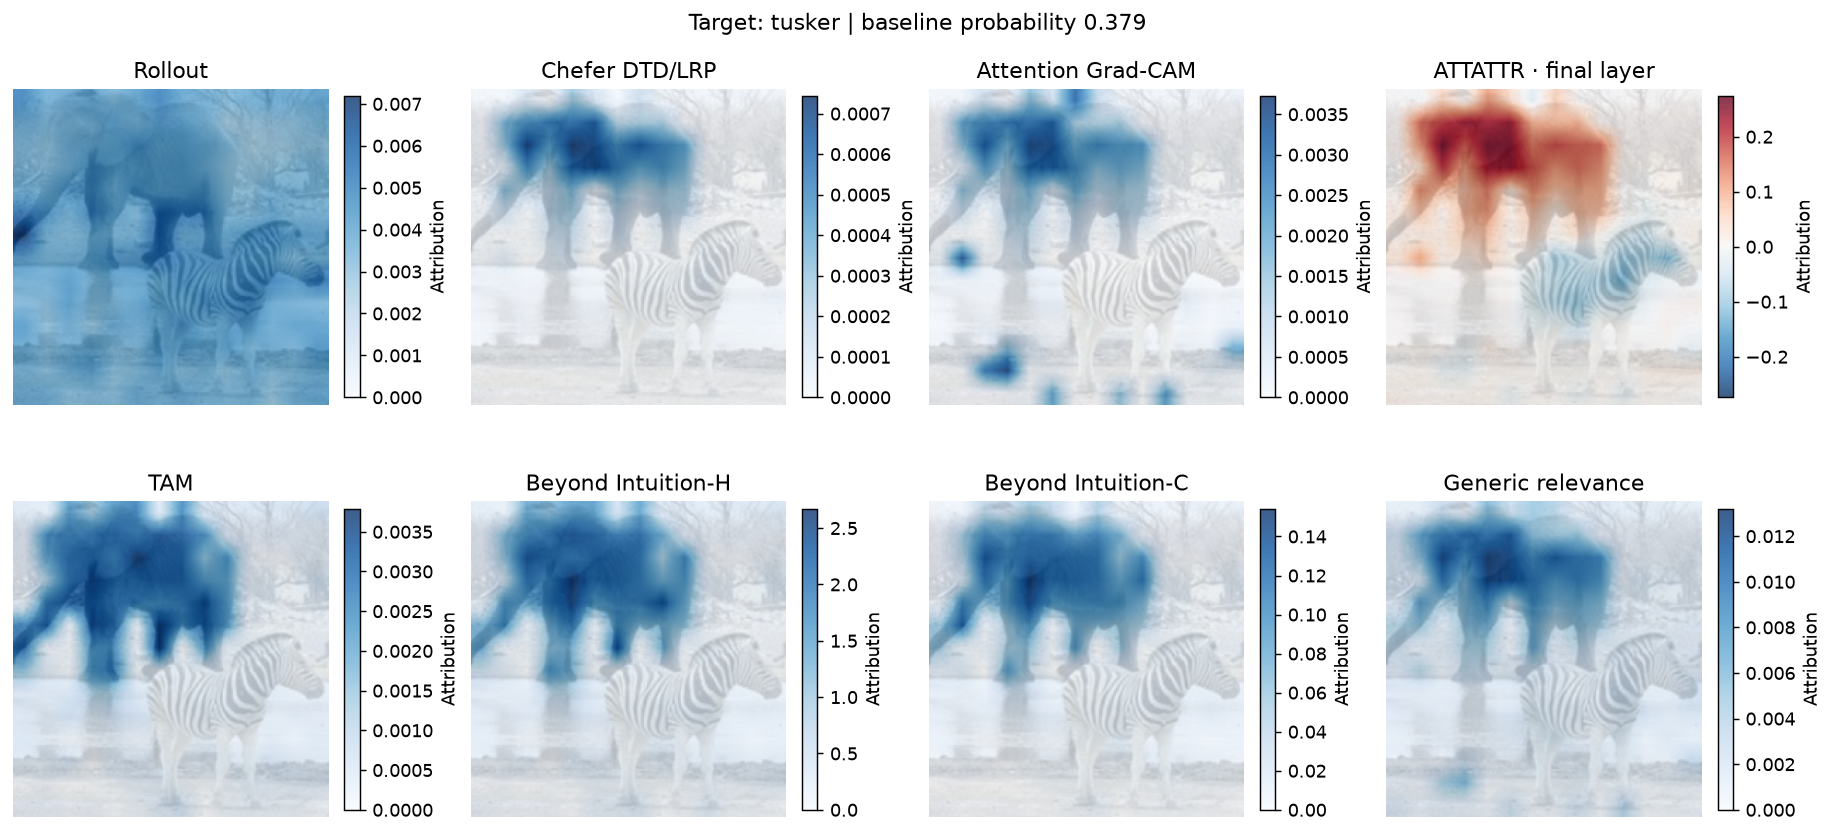

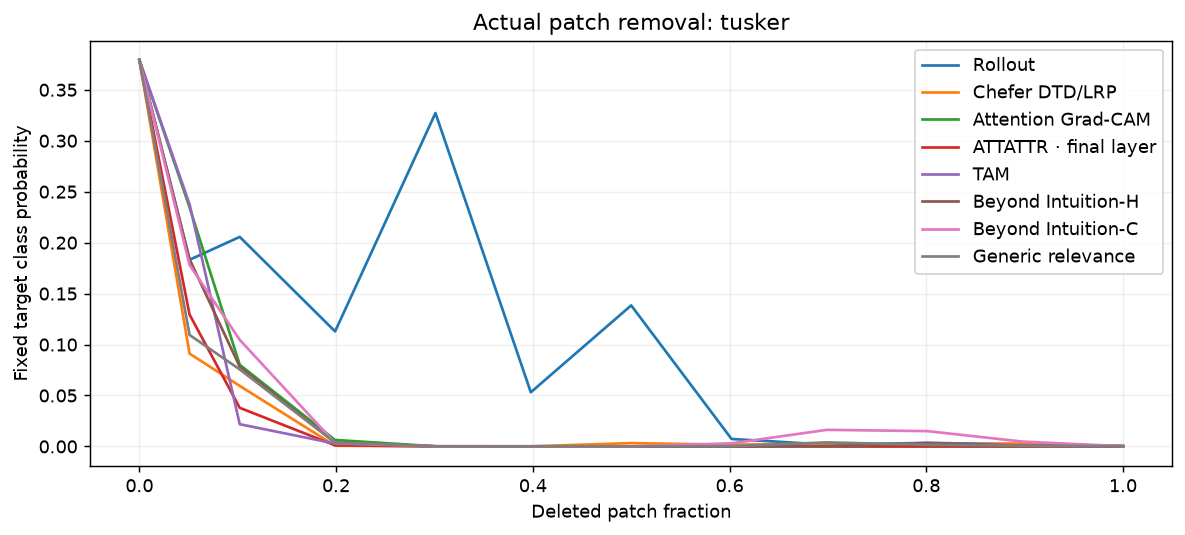

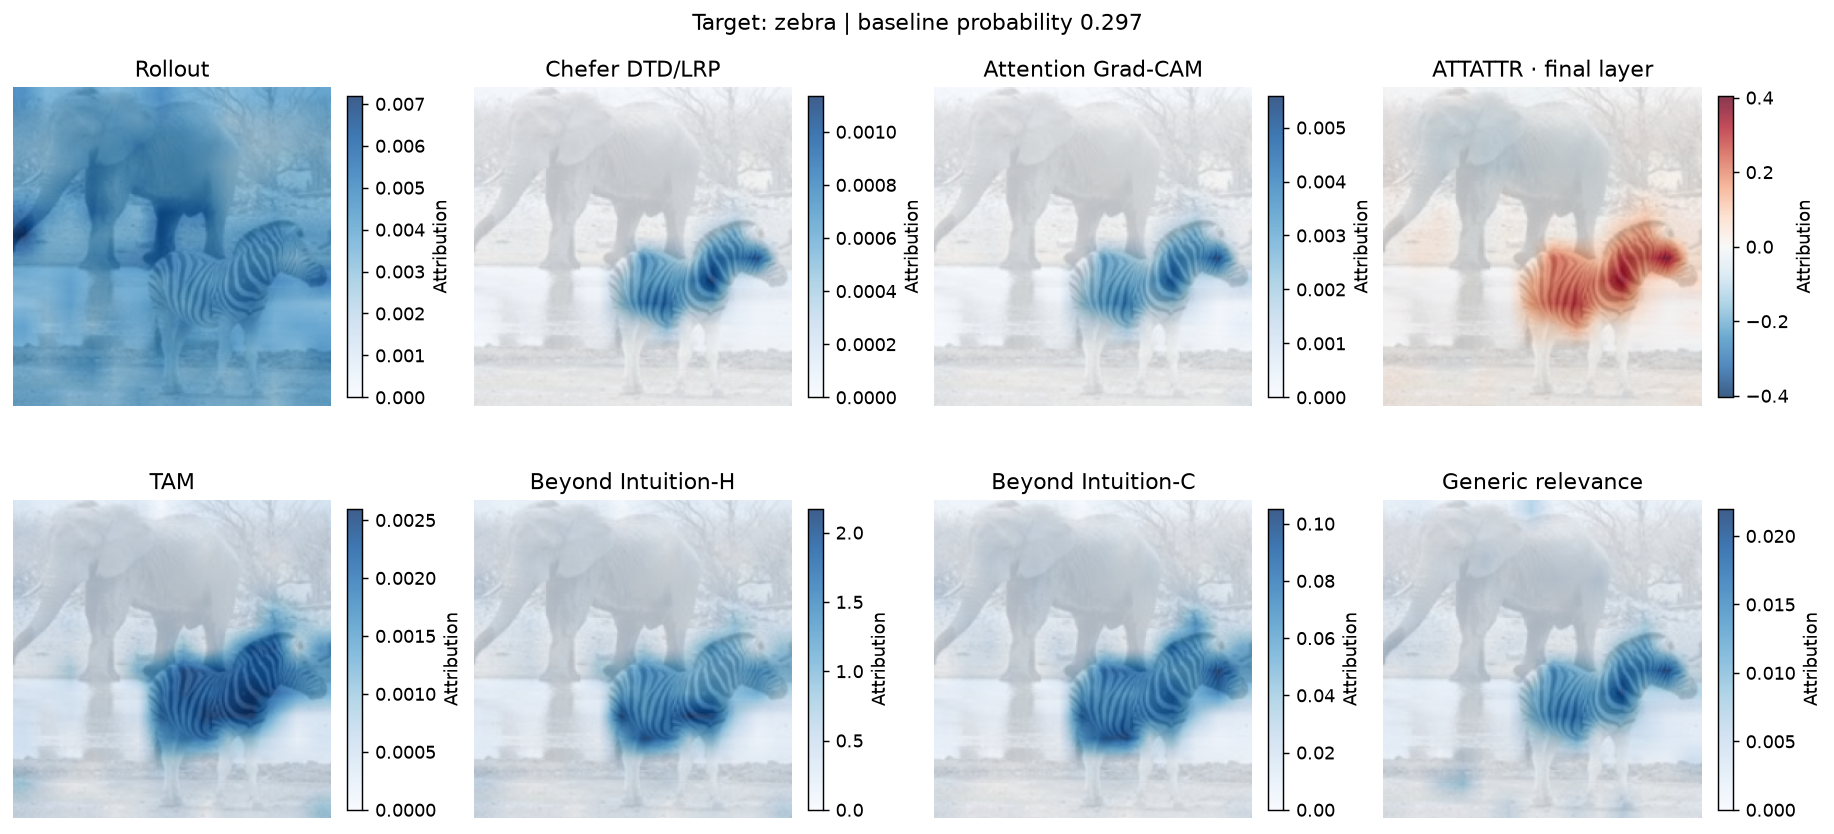

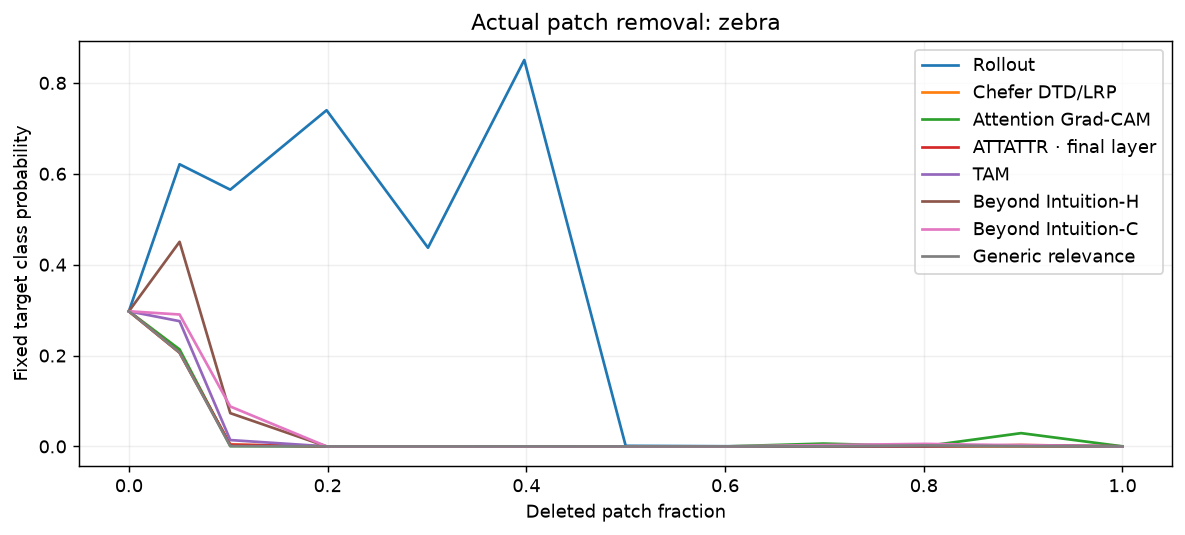

In [2]:
records = [load_snapshot(f"attention_comparison/{sample}.json") for sample in ("catdog", "el2")]
for record in records:
    image = load_image(Path(record["crop_png_base64"]).name)
    print("Input:", record["id"], "| model:", record["model"])
    for target in record["targets"]:
        maps = {record["method_names"][name]: matrix for name, matrix in target["maps"].items()}
        signed = {record["method_names"][name]: name == "attattr" for name in target["maps"]}
        fig, axes = plot_attention_comparison(image, maps, grid_shape=record["grid_shape"], columns=4,
                                             signed=signed, alpha=.78)
        fig.suptitle(f"Target: {target['label']} | baseline probability {target['baseline_probability']:.3f}")
        show_figure(fig)
        deletion = target["deletion"]
        curves = {record["method_names"][name]: {"x": deletion["fractions"], "y": series["probabilities"]}
                  for name, series in deletion["curves"].items()}
        ax = plot_intervention_curves(curves, xlabel="Deleted patch fraction", ylabel="Fixed target class probability",
                                      title=f"Actual patch removal: {target['label']}")
        show_figure(ax.figure)

**How to read:** every map uses the same 14×14 processed-image grid. Rollout is independent of the class; gradient/integrated methods depend on the selected class score. Deletion replaces the highest-ranked complete patches with training-mean RGB and runs the model again. Curves can be non-monotonic. Map sharpness alone is not a faithfulness metric. DTD/LRP is shown only for the supported ViT backend; it is not substituted into VLMs.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [3]:
if RERUN:
    import torch
    from transformers import ViTForImageClassification
    from vlm_probing.metrics import ClassScore
    from demos.runtime import attention_methods
    model_id = os.environ.get("VLM_PROBING_VIT_MODEL", "google/vit-base-patch16-224")
    device = os.environ.get("VLM_PROBING_DEVICE", "cuda:0" if torch.cuda.is_available() else "cpu")
    model = ViTForImageClassification.from_pretrained(model_id, attn_implementation="eager").to(device).eval()
    probe = Prober(model)
    # Use the bundled author's already resized/cropped image, normalized to [-1,1].
    image = load_image(Path(records[0]["crop_png_base64"]).name)
    pixels = torch.from_numpy(np.asarray(image).copy()).permute(2,0,1)[None].float().to(device) / 255
    inputs = {"pixel_values": (pixels - .5) / .5}
    metric = ClassScore(records[0]["targets"][0]["class_id"], kind="logit")
    results = {name: method.run(inputs, metric=metric)
               for name, (method, _) in attention_methods(probe, queries=[0], keys="visual", steps=20).items()}
    fig, axes = plot_attention_comparison(image, results, grid_shape=(14,14), query_positions=[0],
                                         visual_positions=list(range(1,197)), columns=4,
                                         signed={name:name=="ATTATTR" for name in results})
    show_figure(fig)
    print("Fresh model:", model_id, "(default HF checkpoint differs from the archived author checkpoint)")
else:
    print("Fresh inference skipped.")

Fresh inference skipped.


## Sources and interpretation

**Images and author checkpoint:** [Transformer Explainability repository](https://github.com/hila-chefer/Transformer-Explainability), commit recorded in snapshots. Illustrative images are not a held-out benchmark. **Methods:** [Rollout](https://arxiv.org/abs/2005.00928), [Grad-CAM](https://arxiv.org/abs/1610.02391), [Attention Attribution](https://arxiv.org/abs/2004.11207), [Transformer Explainability / DTD-LRP](https://arxiv.org/abs/2012.09838), [TAM](https://xai4debugging.github.io/files/papers/explaining_information_flow_in.pdf), [Beyond Intuition](https://openreview.net/forum?id=rm0zIzlhcX), [Generic Attention Explainability](https://arxiv.org/abs/2103.15679).

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.